In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
stock = yf.download("TCS.ns", start="2020-01-01", end="2024-01-01")
stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2020-01-01,1841.149658,1854.994638,1829.597797,1841.489333,1354908
2020-01-02,1832.698242,1851.639805,1825.520891,1851.639805,2380752
2020-01-03,1869.222046,1888.206117,1838.091785,1838.091785,4655761
2020-01-06,1869.052368,1890.711954,1858.392413,1872.917159,3023209
2020-01-07,1873.638916,1881.113430,1854.909706,1869.094568,2429317


In [3]:
stock.info()
stock.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 992 entries, 2020-01-01 to 2023-12-29
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, TCS.NS)   992 non-null    float64
 1   (High, TCS.NS)    992 non-null    float64
 2   (Low, TCS.NS)     992 non-null    float64
 3   (Open, TCS.NS)    992 non-null    float64
 4   (Volume, TCS.NS)  992 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 46.5 KB


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
count,992.000000,992.000000,992.000000,992.000000,9.920000e+02
mean,2735.253861,2762.053807,2708.939625,2736.141637,2.759584e+06
std,517.316219,516.446040,516.443970,517.238781,1.720403e+06
min,1403.242798,1445.348208,1282.137060,1337.511997,2.609490e+05
25%,2518.373657,2541.032669,2494.989805,2516.285111,1.673038e+06
50%,2886.432983,2911.959778,2861.753736,2888.214691,2.293026e+06
75%,3107.209351,3127.970346,3080.941492,3108.615482,3.265962e+06
max,3547.731934,3610.215093,3519.385337,3545.067754,1.983933e+07


In [4]:
stock.isnull().sum()
stock = stock.dropna()

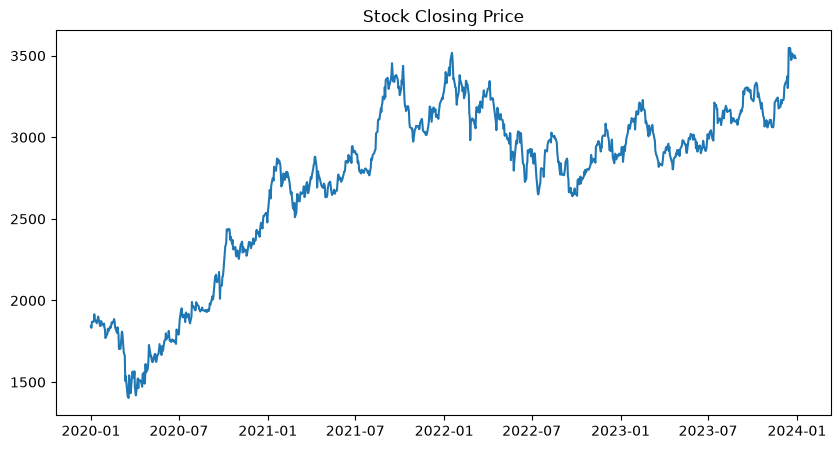

In [5]:
plt.figure(figsize=(10,5))
plt.plot(stock['Close'])
plt.title("Stock Closing Price")
plt.show()

In [6]:
stock['MA50'] = stock['Close'].rolling(window=50).mean()

In [7]:
stock['MA200'] = stock['Close'].rolling(window=200).mean()

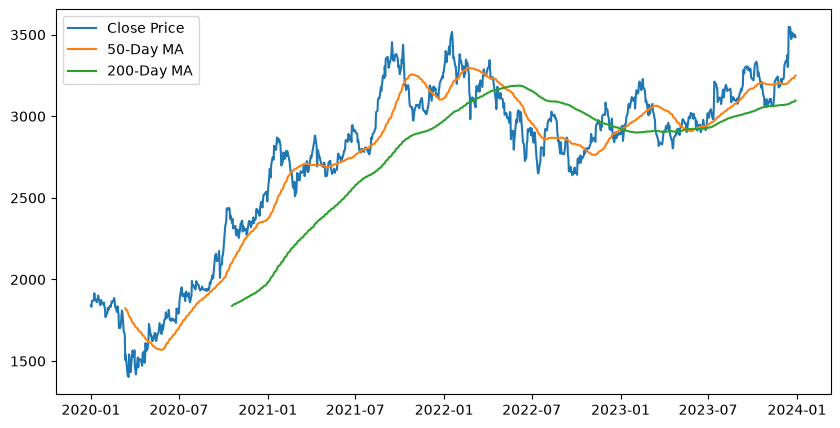

In [8]:
plt.figure(figsize=(10,5))
plt.plot(stock['Close'], label='Close Price')
plt.plot(stock['MA50'], label='50-Day MA')
plt.plot(stock['MA200'], label='200-Day MA')
plt.legend()
plt.show()

In [9]:
stock['Daily Return'] = stock['Close'].pct_change()

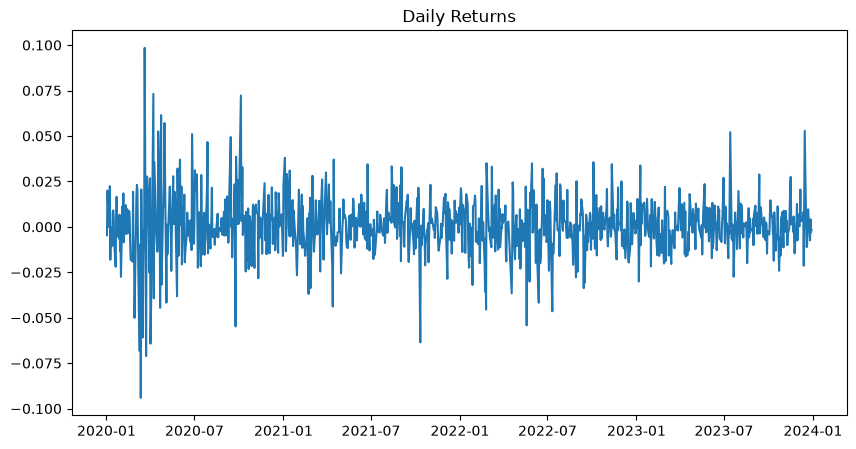

In [10]:
plt.figure(figsize=(10,5))
plt.plot(stock['Daily Return'])
plt.title("Daily Returns")
plt.show()

In [11]:
volatility = stock['Daily Return'].std()
print("Volatility:", volatility)

Volatility: 0.015896552956401605


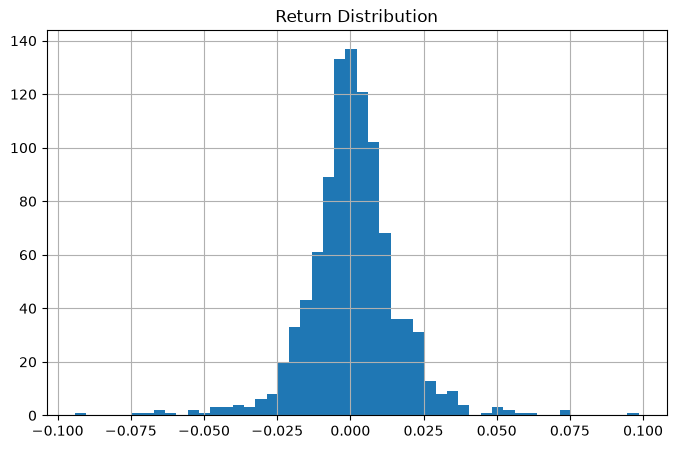

In [12]:
plt.figure(figsize=(8,5))
stock['Daily Return'].hist(bins=50)
plt.title("Return Distribution")
plt.show()

In [15]:
stocks = ['AAPL', 'GOOG', 'TSLA']

In [16]:
import yfinance as yf

stocks = ['AAPL', 'GOOG', 'TSLA']

data = yf.download(stocks, start="2022-01-01")['Close']

print(data.head())

[*********************100%***********************]  3 of 3 completed

Ticker            AAPL        GOOG        TSLA
Date                                          
2022-01-03  177.939728  143.806610  399.926666
2022-01-04  175.681381  143.154343  383.196655
2022-01-05  171.008255  136.450455  362.706665
2022-01-06  168.153549  136.348816  354.899994
2022-01-07  168.319763  135.807129  342.320007


In [17]:
returns = data.pct_change()
returns = returns.dropna()   

In [18]:
correlation = returns.corr()
print(correlation)


Ticker      AAPL      GOOG      TSLA
Ticker                              
AAPL    1.000000  0.558083  0.494437
GOOG    0.558083  1.000000  0.429626
TSLA    0.494437  0.429626  1.000000
